In [10]:
#!/Users/michael/envs/bsb/bin/python
# adapted from https://trvrm.github.io/fractal-dimension.html

import numpy as np
import skimage
import matplotlib.pyplot as plt
from skimage import io
from skimage.filters import threshold_otsu
from skimage.color import rgb2gray
from skimage.util import crop, invert
from scipy.stats import linregress
import math
import os
import sys
from skimage.measure import label, regionprops

# if len(sys.argv) < 3:
# 	print("missing parameters!")
# 	print("usage: fractalDim.py seg_dir color_dir v d")
# 	print("seg_dir is 'path/to/segmentation/images', color_dir is 'path/to/color/images, v visualizes each result")
# 	print("d prints the output for each image as the fractal dimension is calculated")
# 	print("use `fractalDim.py seg_dir color_dir v > results.txt` to save results")
# 	sys.exit()

# handle args
# segs = sys.argv[1]
# clrs = sys.argv[2]
# viz = False
# disp = False
# if sys.argv[3] == "v":
# 	viz = True
# if sys.argv[4] == "d":
# 	disp = True



"""
	Read the image and preprocess for fractal dimension calculation
"""
def loadImage(img):
	im = skimage.io.imread(img)
	ht, wd = im.shape[0], im.shape[1]
	imb = binaryThreshold(im)
	imn = invert(imb)
	return imn, ht, wd

"""
	Apply Otsu thresholding to the image and binarize the passed image 
"""
def binaryThreshold(img):
	thresh = threshold_otsu(img)
	binary =  img > thresh
	return binary

def fracable(img):
	return 0 in set(img.flatten())

"""
	Successively crop the image and count the number of tiles containing black pixels
"""
def countBoxes(img, length, height, width):
	h, w = height, width
	boxCount = 0
	specialCount = 0
	for x in range(w//length):
		for y in range(h//length):
			#img[b:d, a:c] === crop((a, b, c, d))
			a = x*length
			b = y*length
			c = (x+1)*length
			d = (y+1)*length
			choppedImg = img[b:d, a:c]
			boxCount+=1
			if fracable(choppedImg):
				specialCount+=1
	return specialCount

"""
	Count the number of boxes at each scale possible for the dimensions of the given image. 
	Generates a pair representing the numerator and denominator of the fractal dimension equation.
	A list of these pairs is used to calculate the slope when the loop exits.
"""
def getBoxCounts(img, height, width):
	length = min(height, width)
	while length > 5:
		special = countBoxes(img, length, height, width)
		yield math.log(1.0/length), math.log(special)
		length = (length//2)

"""
	Stores all of the (scale ,box count) pairs for the final fractal dimension calculation
"""
def allCounts(img, height, width):
	return (list(getBoxCounts(img, height, width)))

"""
	Calculate the slope between the number of boxes and scales with linregress; return fractal 
	dimension value
"""
def getFractalDimension(img, height, width):
	f = allCounts(img, height, width)
	x = [g[0] for g in f]
	y = [g[1] for g in f]
	fd = linregress(x,y).slope
	return fd



import os
import numpy as np
import skimage
from skimage.color import rgb2gray
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt

def loadImage(image_path):
    """
    加载图像并返回图像数据及其尺寸
    
    :param image_path: 图像文件路径
    :return: 图像数据, 高度, 宽度
    """
    img = skimage.io.imread(image_path)
    if len(img.shape) > 2:
        img = rgb2gray(img)
    h, w = img.shape
    return img, h, w

def identify_connected_components(skeleton):
    """
    标识骨架图中的独立连通组件
    
    :param skeleton: 骨架图像
    :return: 各连通组件的坐标列表
    """
    labeled_image, num_labels = label(skeleton, connectivity=2, return_num=True)
    components = [region.coords for region in regionprops(labeled_image)]
    return components

def remove_non_vessels(segImg, components, results):
    """
    移除非血管组件并生成新的图像
    
    :param segImg: 原始分割图像
    :param components: 连通组件列表
    :param results: 每个组件的判定结果（'yes'/'no'数组）
    :return: 移除非血管组件后的图像
    """
    # 初始化为全0（全黑）的图像
    tissue = np.zeros_like(segImg)
    not_tissue = np.zeros_like(segImg)
    
    # 只在被标记为血管的连通组件位置设置为1
    for component, is_vessel in zip(components, results):
        if is_vessel == 'yes':
            for coord in component:
                tissue[coord[0], coord[1]] = 1
        else:
            for coord in component:
                not_tissue[coord[0], coord[1]] = 1
    
    return tissue, not_tissue

def process_vessel_images(gtdir, segs, segs2):
    """
    处理血管图像数据
    
    :param gtdir: 地面真值目录
    :param segs: 第一个分割结果目录
    :param segs2: 第二个分割结果目录
    """
    # 获取文件列表
    slist = sorted([f for f in os.listdir(segs) if f != '.DS_Store'])
    slist2 = sorted([f for f in os.listdir(segs2) if f != '.DS_Store'])
    gtlist = sorted([f for f in os.listdir(gtdir) if f != '.DS_Store'])
    
    # 处理每张图片
    for i in range(len(slist)):
        # 加载图像
        gt = os.path.join(gtdir, gtlist[i])
        simg = os.path.join(segs, slist[i])
        simg2 = os.path.join(segs2, slist2[i])
        
        # 加载并预处理分割结果
        segImg, h, w = loadImage(simg)  # 不确定的
        segImg2, h, w = loadImage(simg2)  # 确定的0.5
        # segImg = (segImg == 1).astype(np.uint8)
        # segImg2 = (segImg2 == 0).astype(np.uint8)
        
        # 加载地面真值
        gtImg = skimage.io.imread(gt)
        gtImg = rgb2gray(gtImg)
         
        # 计算差异：提取在segImg中但不在segImg2中的区域
        # 使用逻辑运算代替直接相减
        U = np.logical_or(segImg, segImg2).astype(np.uint8)
        
        # 识别连通分量
        components = identify_connected_components(segImg)
        
        # 分析每个连通分量
        results = []
        for component in components:
            pixel_count = len(component)  # 总像素数
            vessel_pixel_count = sum(gtImg[coord[0], coord[1]] > 0 for coord in component)
            
            # 如果前景像素占比超过50%，则认为是血管
            is_vessel = (vessel_pixel_count / pixel_count) > 0.7
            results.append('yes' if is_vessel else 'no')
        
        results = np.array(results)
        
        # 移除非血管组件
        tissue, not_tissue = remove_non_vessels(segImg, components, results)
        plt.imsave(os.path.join('/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/test/tissue', f'cleaned_{slist[i]}'), tissue)
        plt.imsave(os.path.join('/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/test/not_tissue', f'cleaned_{slist[i]}'), not_tissue)
        
        new_add = np.logical_or(tissue, segImg2).astype(np.uint8)
        # 可视化结果
        # plt.figure(figsize=(15, 5))
        
        # plt.subplot(141)
        # plt.imshow(segImg, cmap='gray')
        # plt.title('Original Segmentation')
        
        # plt.subplot(142)
        # plt.imshow(segImg2, cmap='gray')
        # plt.title('Second Segmentation')
        
        # plt.subplot(143)
        # plt.imshow(tissue, cmap='gray')
        # plt.title('Cleaned Result')
        
        # plt.subplot(144)
        # plt.imshow(new_add, cmap='gray')
        # plt.title('Cleaned Result')
        # plt.show()

if __name__ == "__main__":
    # 设置路径
    gtdir = '/home/xkw/pxlames/segmentation/data/FIVE/test/1st_manual'
    segs = '/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/test/Ufolder' # 做差腐蚀后的
    segs2 = '/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE3/test/Cfolder'
    tissue = '/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/test/tissue'
    
    # 处理图像
    process_vessel_images(gtdir, segs, segs2)

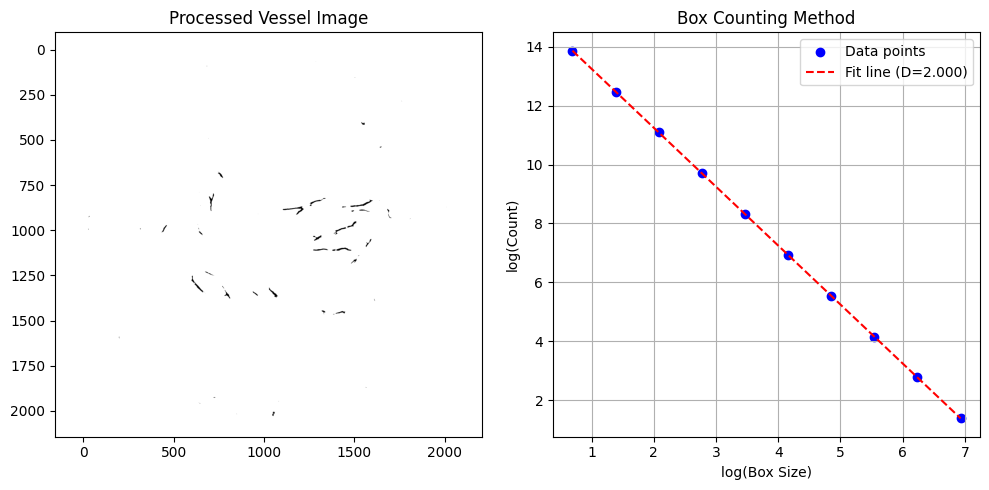

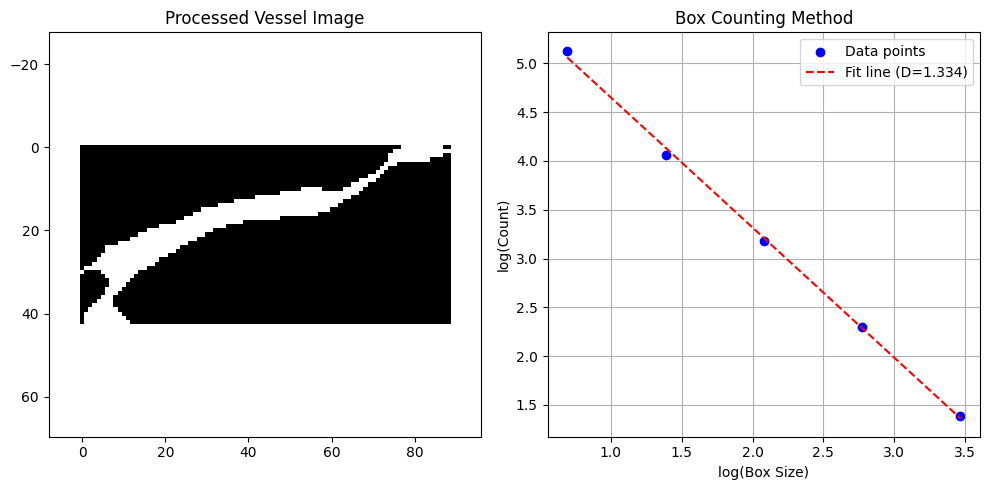

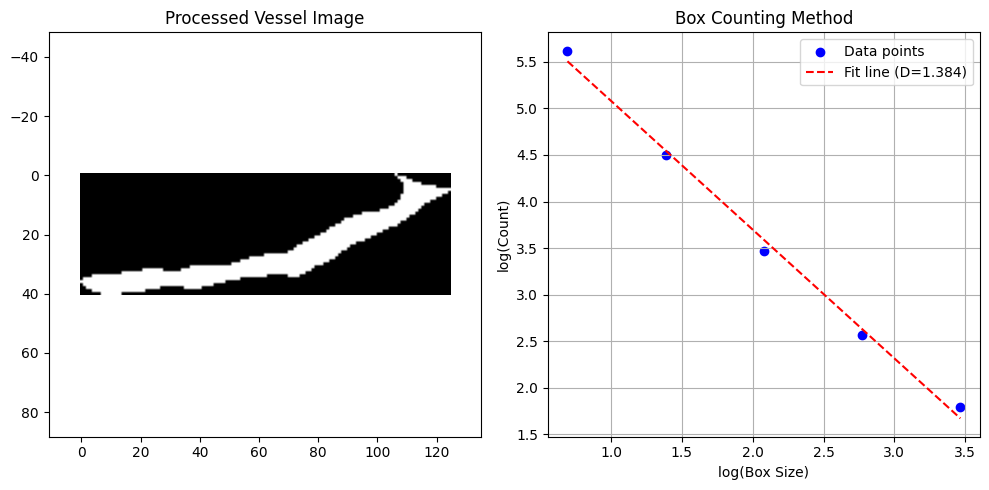

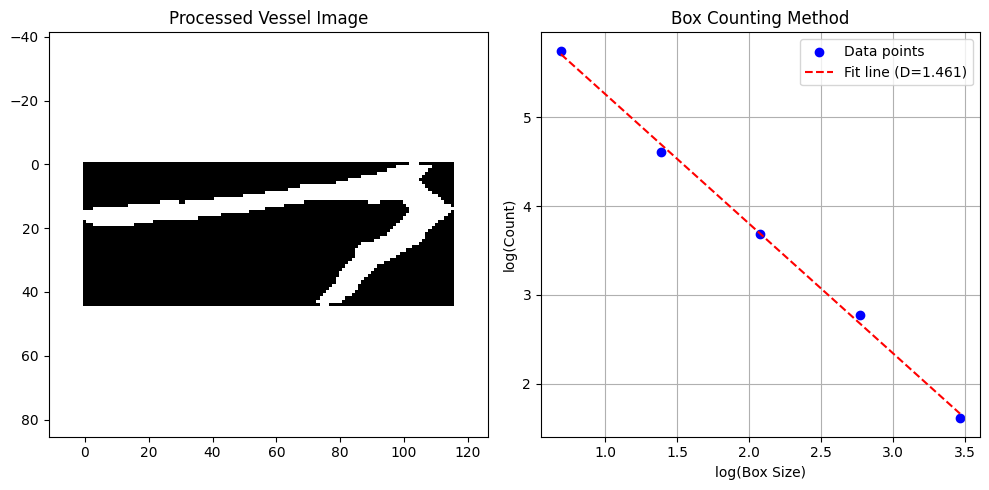

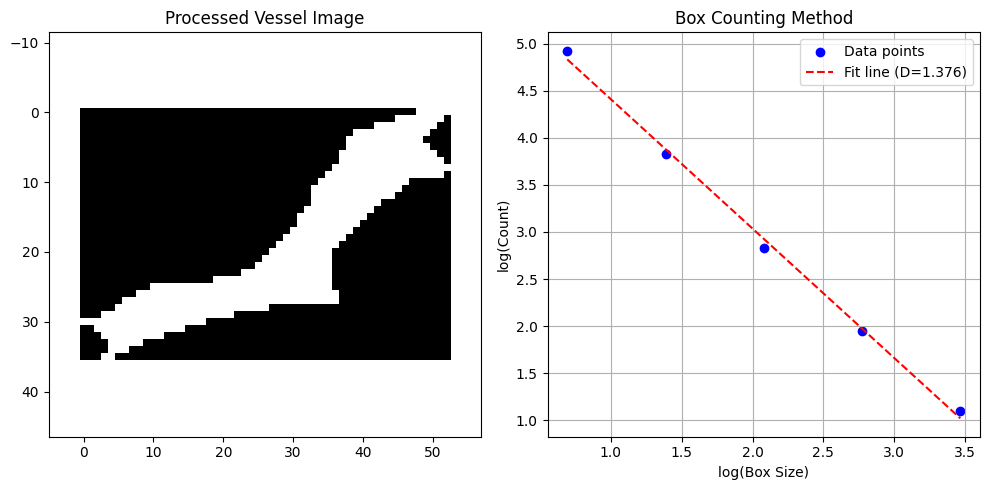

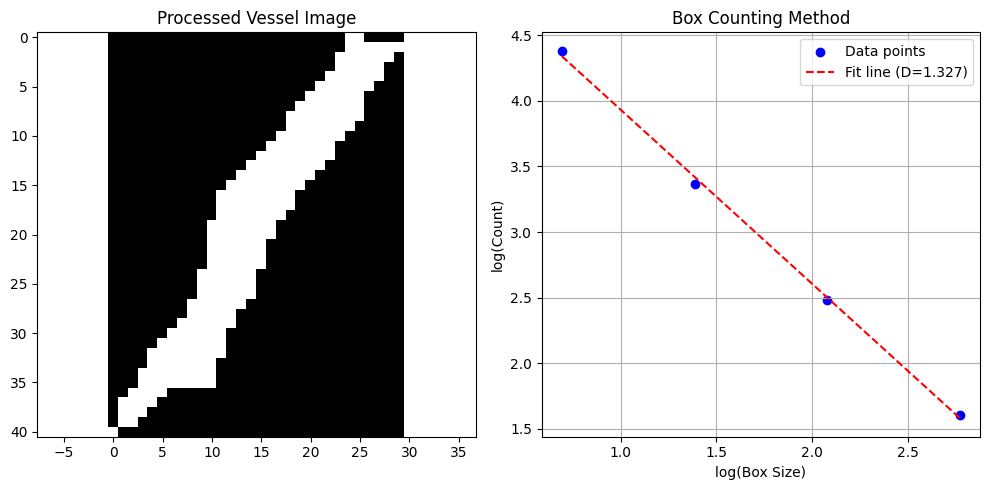

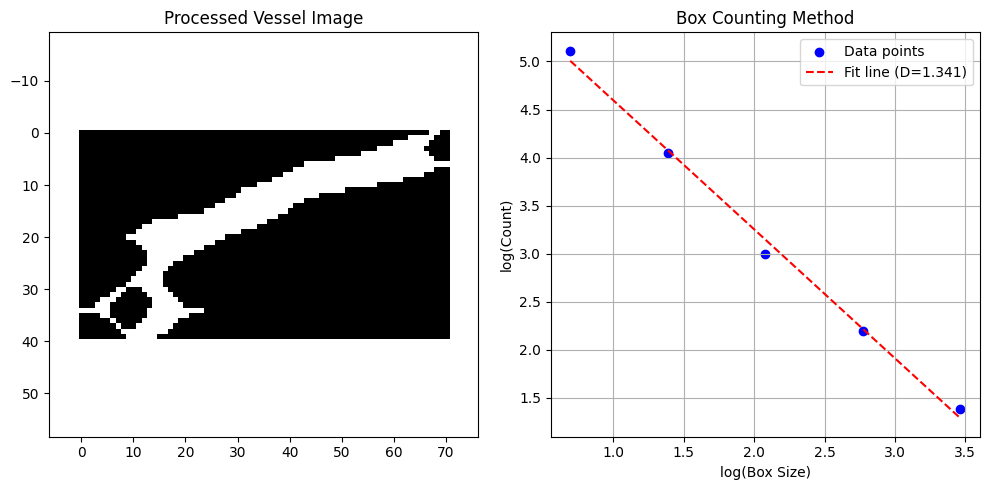

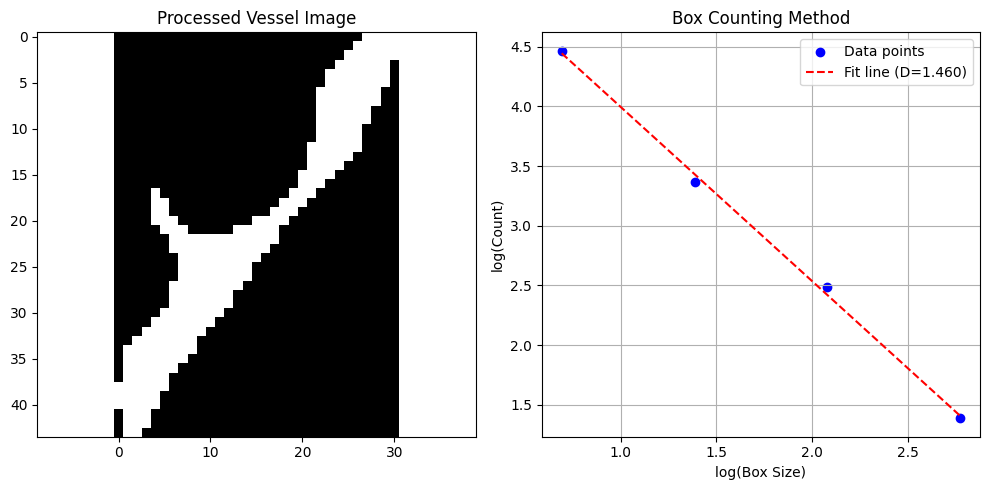

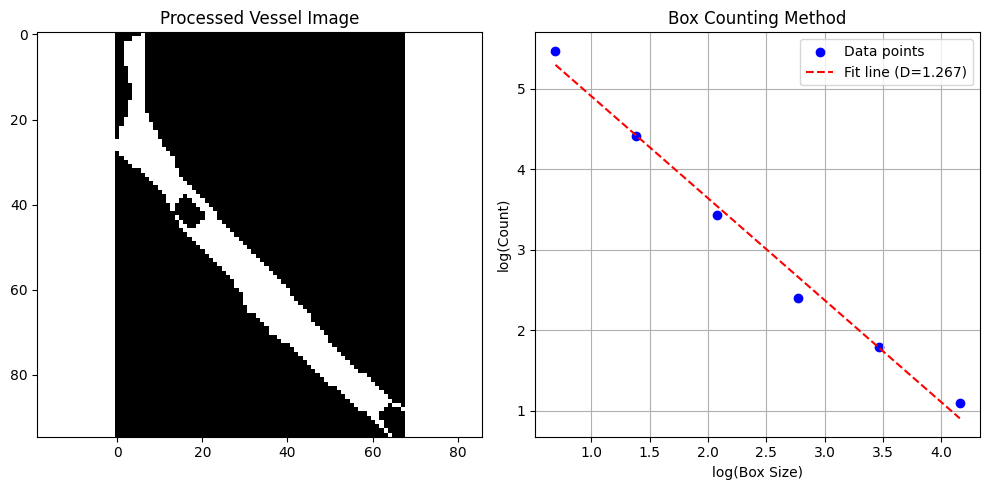

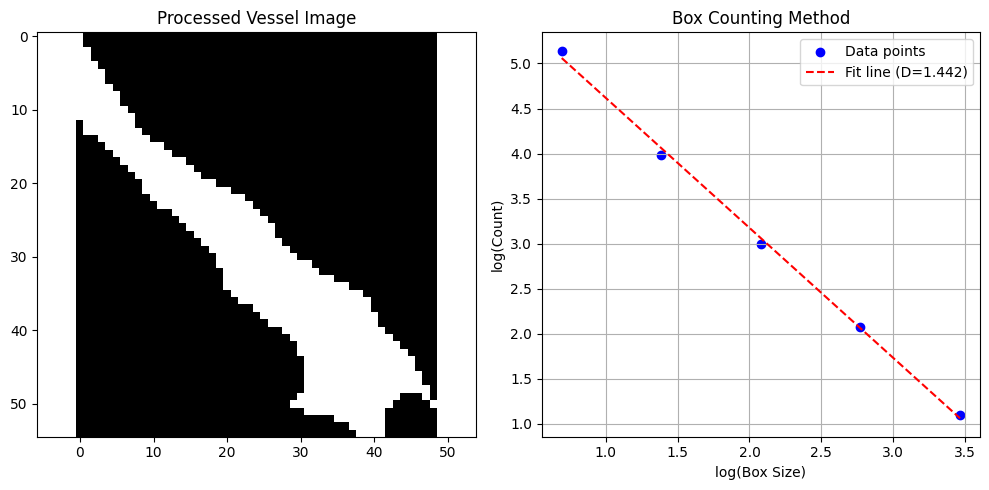

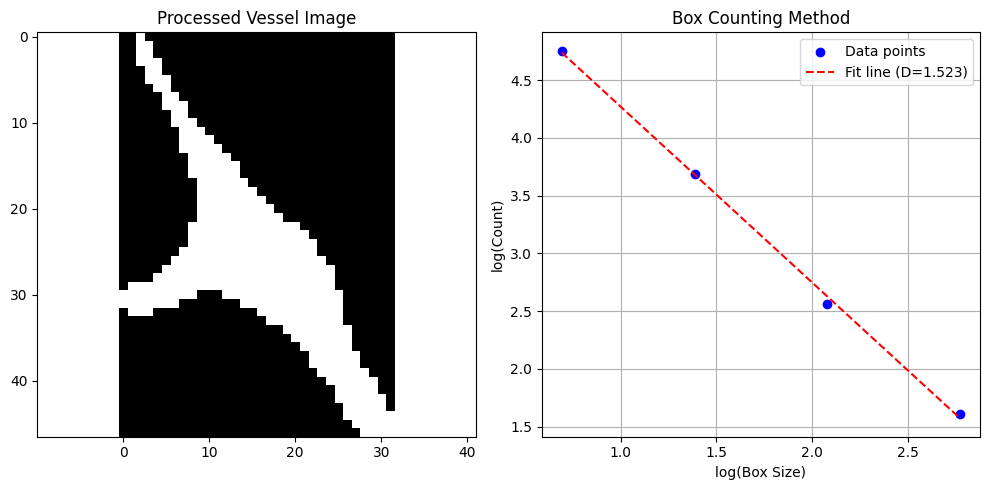

数据已保存到: /home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/test/fd_list


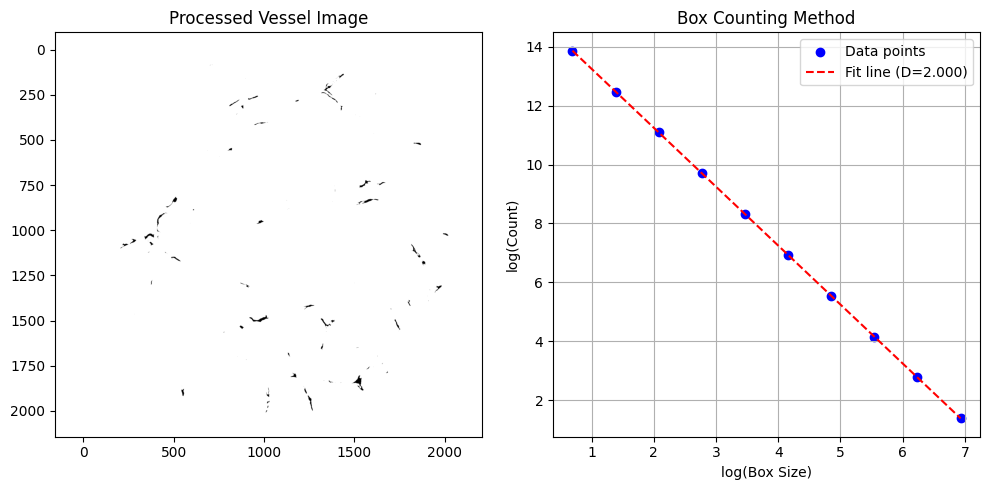

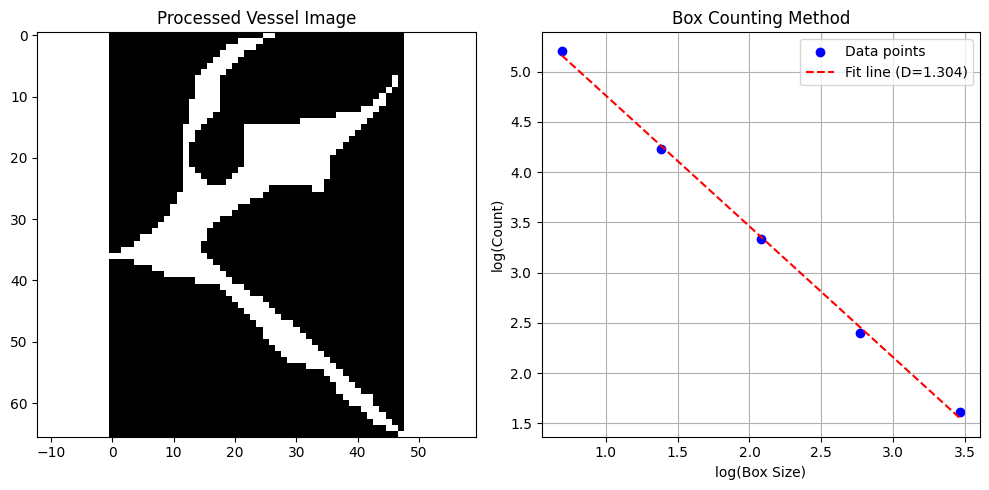

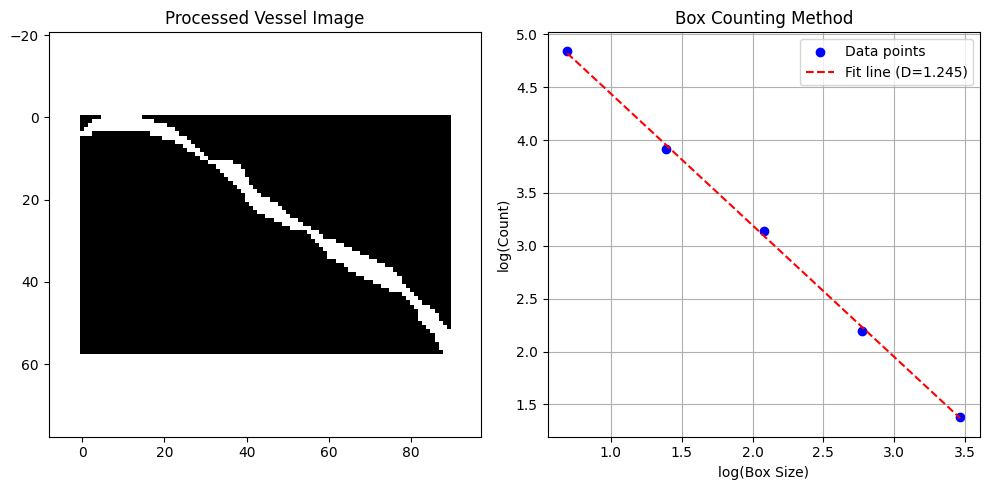

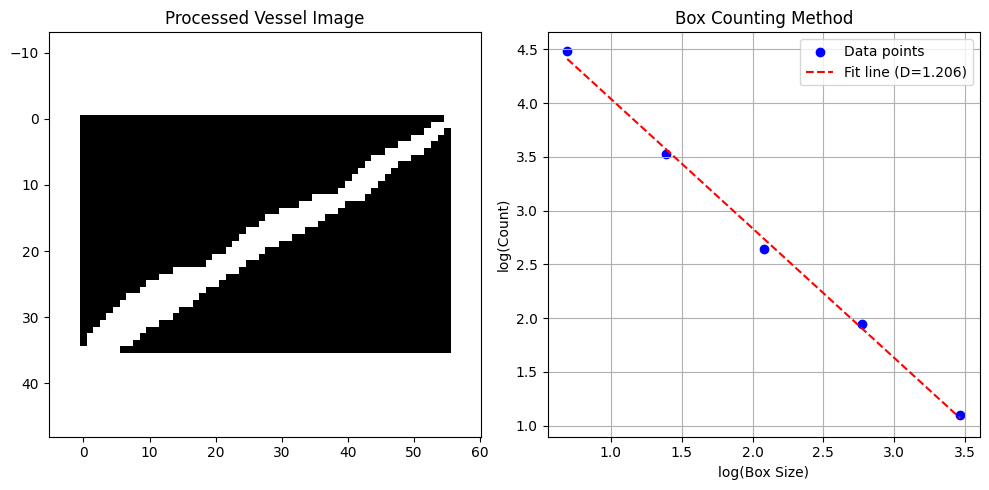

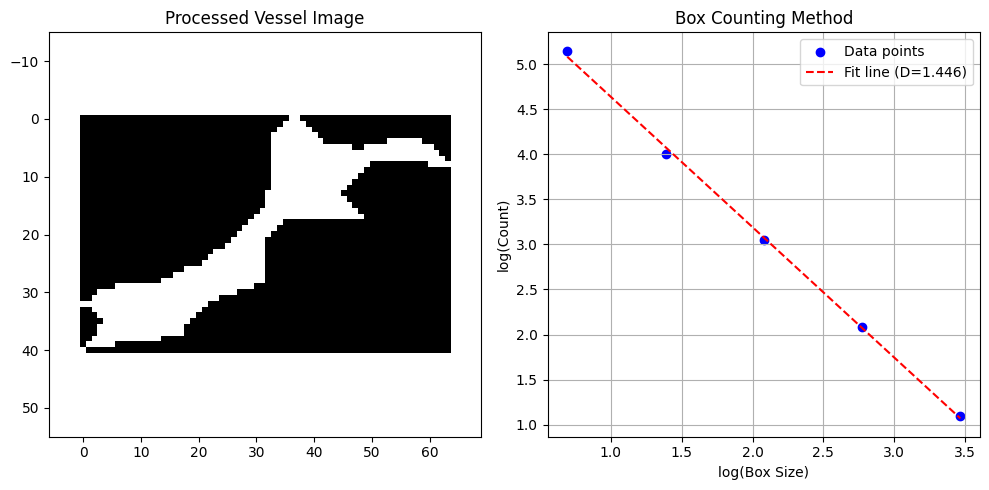

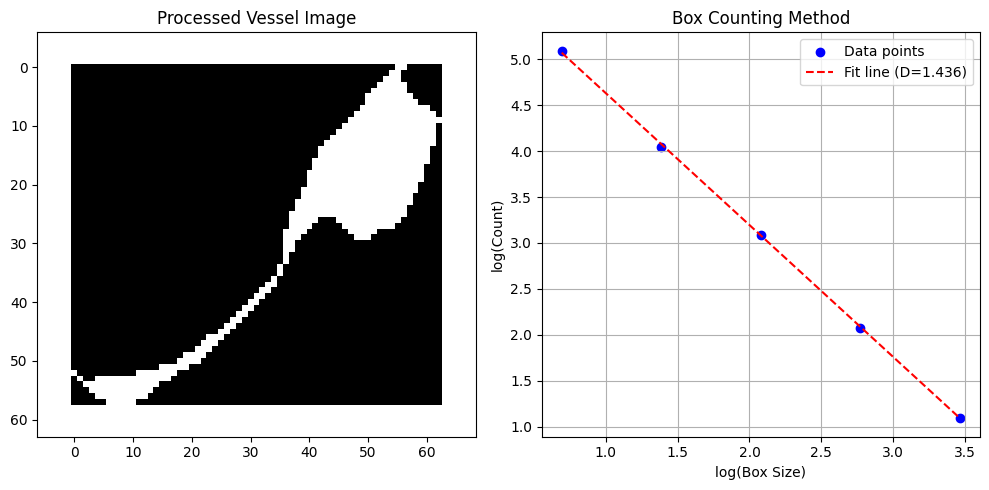

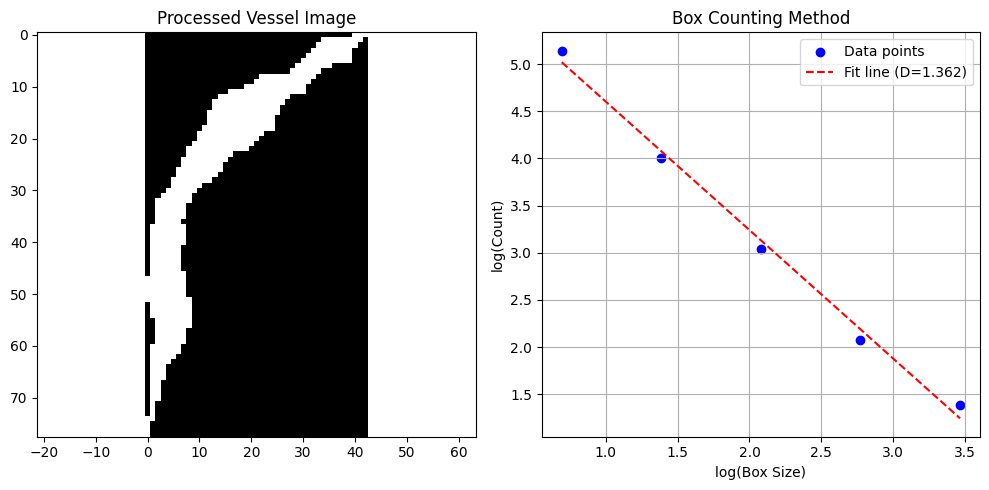

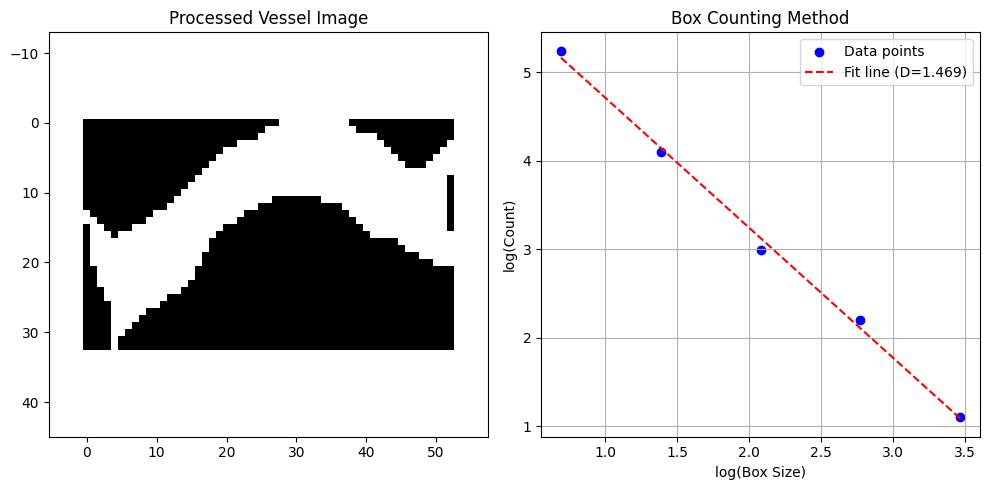

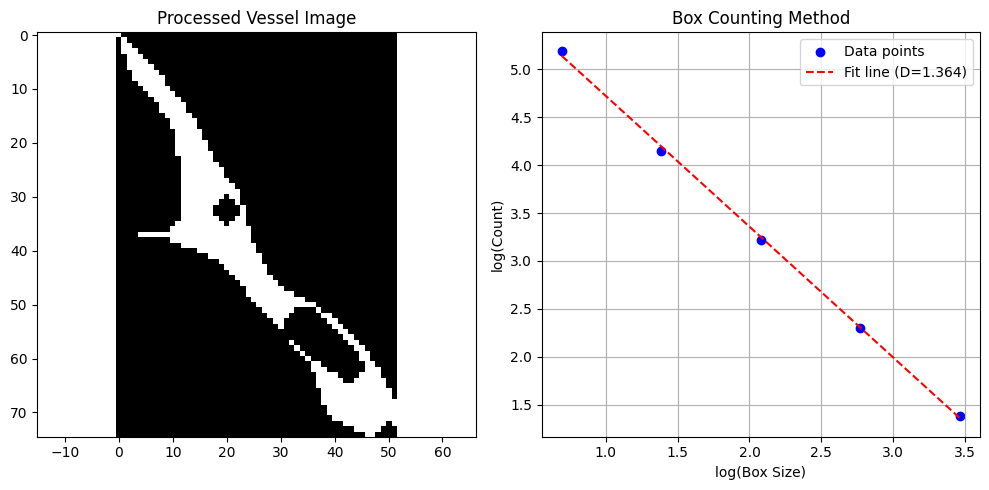

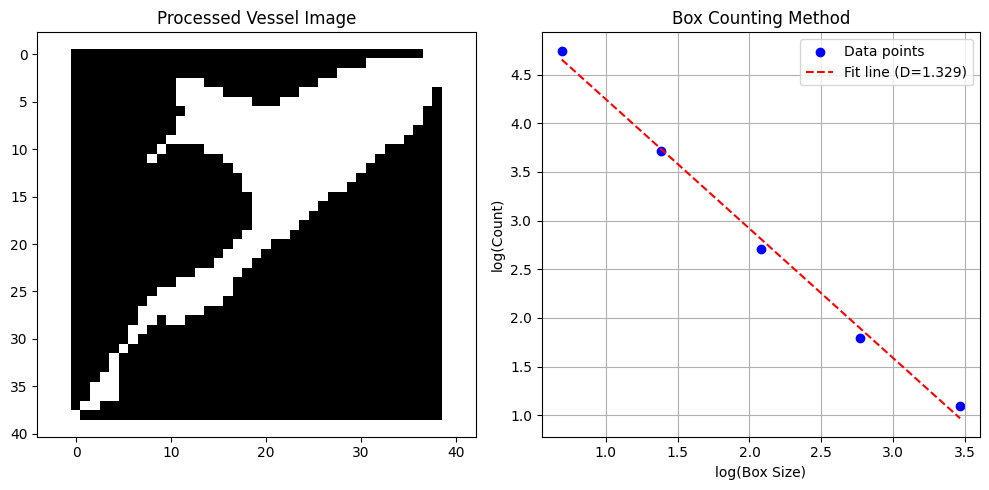

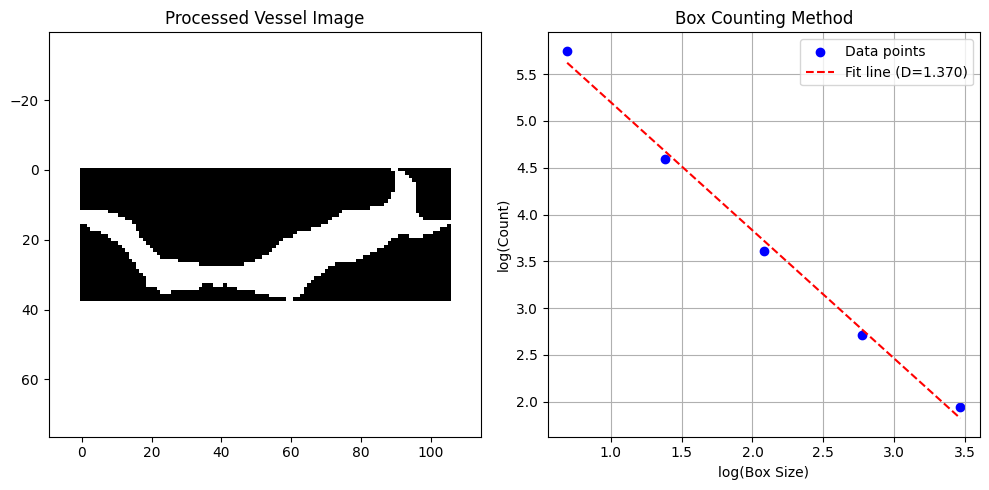

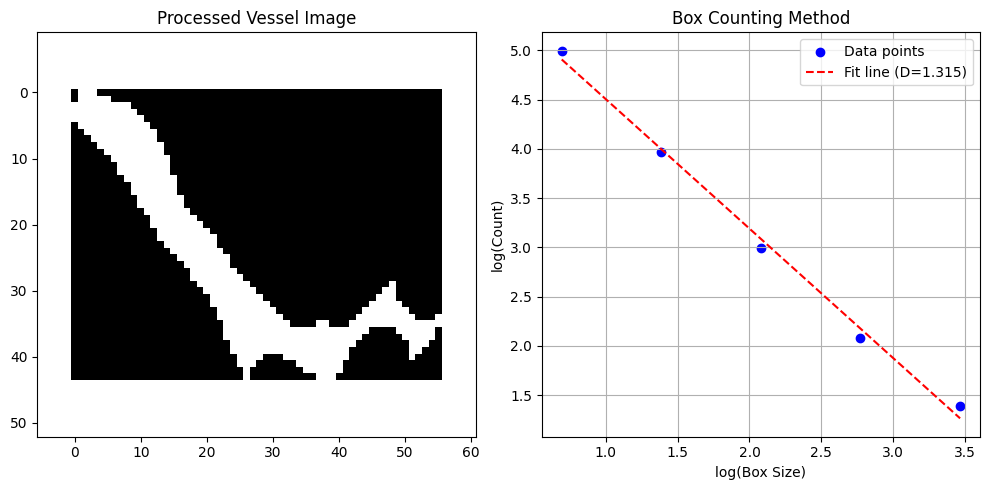

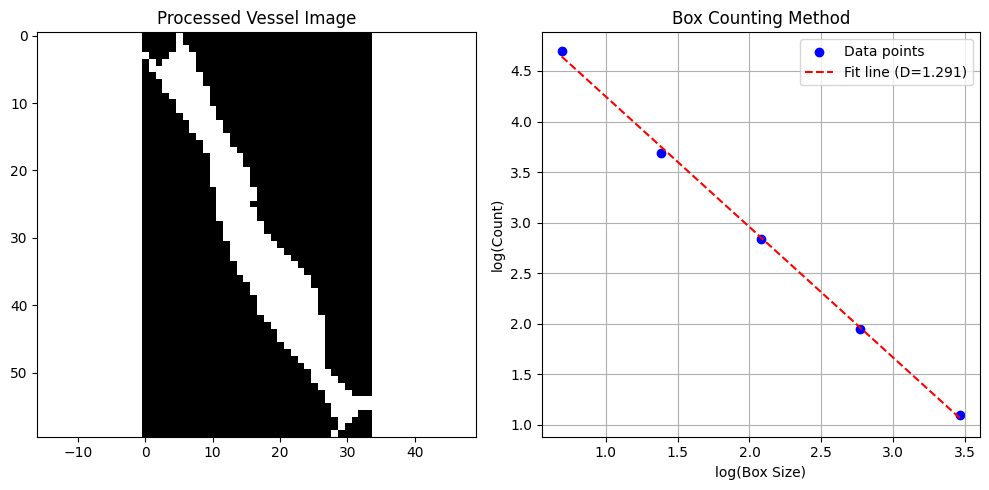

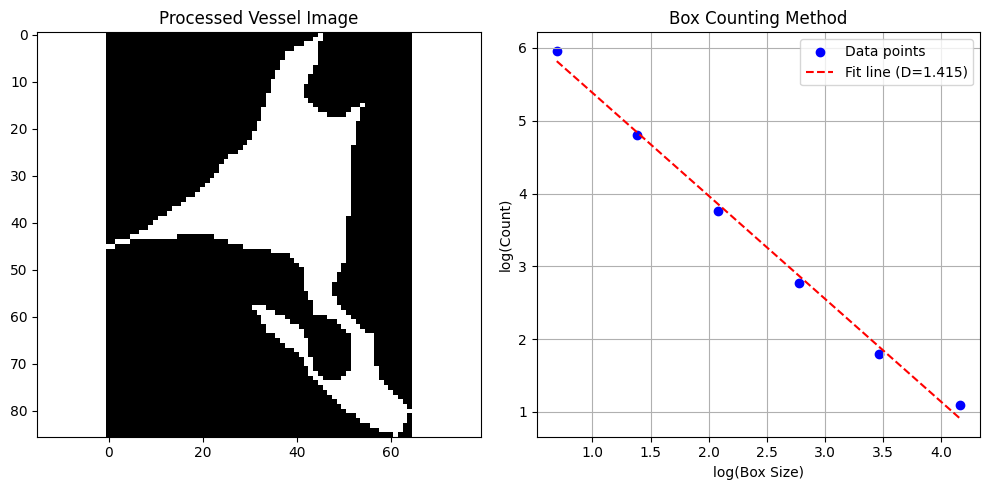

数据已保存到: /home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/test/fd2_list


In [8]:

def identify_connected_components(skeleton):
    """标识骨架图中的独立连通组件"""
    labeled_image, num_labels = label(skeleton, connectivity=2, return_num=True)
    components = [region.coords for region in regionprops(labeled_image)]
    return components

def loadImage(image_path):
    """加载图像并返回图像数据及其尺寸"""
    img = skimage.io.imread(image_path)
    if len(img.shape) > 2:
        img = img[:,:,0]
    h, w = img.shape
    return img, h, w

def countBoxes(img, length, height, width):
    """计算包含前景像素的盒子数量"""
    h, w = height, width
    boxCount = 0
    specialCount = 0
    for x in range(w//length):
        for y in range(h//length):
            a = x*length
            b = y*length
            c = min((x+1)*length, w)
            d = min((y+1)*length, h)
            choppedImg = img[b:d, a:c]
            boxCount += 1
            if np.any(choppedImg == 1):  # 检查是否包含前景像素
                specialCount += 1
    return specialCount

def getBoxCounts(img, height, width):
    """生成不同尺度下的盒子计数"""
    counts = []
    length = min(height, width)
    while length > 5:
        special = countBoxes(img, length, height, width)
        if special > 0:  # 避免取对数时出错
            counts.append((math.log(1.0/length), math.log(special)))
        length = length//2
    return counts

def getFractalDimension(img, height, width):
    """计算分形维数"""
    counts = getBoxCounts(img, height, width)
    if len(counts) < 2:  # 确保有足够的点进行回归
        return 0
    x = [p[0] for p in counts]
    y = [p[1] for p in counts]
    slope, _, _, _, _ = linregress(x, y)  # 正确使用linregress
    return slope



def analyze_single_vessel(component, min_size=30, plot=False):
    """
    分析单个血管连通分量的分形维数
    
    参数:
    component: 连通分量的坐标点列表 shape:(N,2)
    min_size: 最小处理尺寸，小于这个尺寸的连通分量将返回None
    plot: 是否绘制分析过程的图像，默认False
    
    返回:
    fd: 分形维数，如果无法计算则返回None
    """
    
    
    try:
        # 1. 预处理：创建二值图像
        rows = component[:, 0]
        cols = component[:, 1]
        min_row, max_row = np.min(rows), np.max(rows)
        min_col, max_col = np.min(cols), np.max(cols)

        # 计算外接矩形的宽和高
        height = max_row - min_row + 1
        width = max_col - min_col + 1

        # 检查尺寸
        if min(height, width) < min_size:
            # print(f"Warning: Component too small (height={height}, width={width}), skipping...")
            return None

        # 创建矩形图像
        vessel_img = np.zeros((height, width), dtype=np.uint8)

        # 将坐标点映射到新的矩形图像中
        adjusted_rows = rows - min_row
        adjusted_cols = cols - min_col
        vessel_img[adjusted_rows, adjusted_cols] = 1

        if plot:
            # 绘制处理后的血管二值图像
            plt.figure(figsize=(10, 5))
            plt.subplot(121)
            plt.imshow(vessel_img, cmap='gray')
            plt.title('Processed Vessel Image')
            plt.axis('equal')

        # 2. 分形维数计算
        def box_count(img, box_size):
            boxes = np.add.reduceat(
                np.add.reduceat(img, np.arange(0, img.shape[0], box_size), axis=0),
                np.arange(0, img.shape[1], box_size), axis=1
            )
            return len(boxes[boxes > 0])

        # 计算可用的盒子尺寸
        max_power = int(np.log2(min(vessel_img.shape)))
        if max_power < 1:  # 确保至少有一个尺度可用
            # print(f"Warning: Component too small for box counting (max_power={max_power})")
            return None
            
        sizes = []
        counts = []
        for i in range(1, max_power + 1):
            size = 2**i
            if size < min(vessel_img.shape):  # 确保盒子大小不超过图像尺寸
                count = box_count(vessel_img, size)
                if count > 0:  # 只添加有效的计数
                    sizes.append(size)
                    counts.append(count)

        # 检查是否有足够的点进行拟合
        if len(sizes) < 2:
            # print(f"Warning: Not enough points for fitting (points={len(sizes)})")
            return None

        # 通过线性回归计算分形维数
        log_sizes = np.log(sizes)
        log_counts = np.log(counts)
        coeffs = np.polyfit(log_sizes, log_counts, 1)
        fd = -coeffs[0]  # 分形维数是斜率的负值

        if plot:
            # 绘制双对数拟合图
            plt.subplot(122)
            plt.scatter(log_sizes, log_counts, c='blue', label='Data points')
            # 绘制拟合直线
            fit_line = coeffs[0] * log_sizes + coeffs[1]
            plt.plot(log_sizes, fit_line, 'r--', 
                    label=f'Fit line (D={fd:.3f})')
            plt.xlabel('log(Box Size)')
            plt.ylabel('log(Count)')
            plt.title('Box Counting Method')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        # 检查计算结果是否合理
        if not (0 < fd < 2):
            # print(f"Warning: Calculated fractal dimension out of range (fd={fd})")
            return None

        return fd

    except Exception as e:
        # print(f"Error during analysis: {str(e)}")
        return None

tissue_dir = '/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/test/tissue'
not_tissue_dir = '/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/test/not_tissue'

tissue_list = sorted([f for f in os.listdir(tissue_dir) if f != '.DS_Store'])
not_tissu_list = sorted([f for f in os.listdir(not_tissue_dir) if f != '.DS_Store'])

Fd1_list = []
 # 处理每张图片
for i in range(len(tissue_list)):
    # 加载图像
    img_path = os.path.join(tissue_dir, tissue_list[i])
    
    # 加载并预处理分割结果
    img, h, w = loadImage(img_path)
    # 创建新的图形窗口
    # plt.figure(figsize=(8, 8))
    # plt.imshow(img, cmap='gray')
    # plt.title(f'Tissue Image: {tissue_list[i]}')
    # plt.axis('on')
    # plt.show()
    if(i == 0):
        plot = True
    else:
        plot = False
    components = identify_connected_components(img)
    for component in components:
        fd = analyze_single_vessel(component,plot=plot)
        if fd is not None:
            Fd1_list.append(fd)

file_path = os.path.join('/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/test', 'fd_list')
with open(file_path, 'w') as f:
    for value in Fd1_list:
        f.write(f"{value}\n")
print(f"数据已保存到: {file_path}")


Fd2_list = []
 # 处理每张图片
for i in range(len(not_tissu_list)):
    # 加载图像
    img_path2 = os.path.join(not_tissue_dir, not_tissu_list[i])
    
    # 加载并预处理分割结果
    img2, h, w = loadImage(img_path2)
    # plt.figure(figsize=(8, 8))
    # plt.imshow(img2, cmap='gray')
    # plt.title(f'Tissue Image: {tissue_list[i]}')
    # plt.axis('on')
    # plt.show()
    
    if(i == 0):
        plot = True
    else:
        plot = False
    components = identify_connected_components(img)    
    for component in components:
        fd = analyze_single_vessel(component,plot=plot)
        if fd is not None:
            Fd2_list.append(fd)

file_path = os.path.join('/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/test', 'fd2_list')
with open(file_path, 'w') as f:
    for value in Fd2_list:
        f.write(f"{value}\n")
print(f"数据已保存到: {file_path}")
    





读取的数据:
[1.9985494117028597, 1.462132242138407, 1.4356979174700824, 1.2566865910263665, 1.146342124963253, 1.4145898985524734, 1.3005216531086499, 1.3934263718721738, 1.3954014507722552, 1.3004753181209137, 1.5670644395199456, 1.3710510504531768, 1.362552250864969, 1.4652092810800585, 1.2157007850599182, 1.3191773181869164, 1.2706949647342363, 1.4615196045198426, 1.298500609621783, 1.3335818329606772, 1.3848013837441893, 1.4919999793053675, 1.3773740204454226, 1.381775569558212, 1.5414916418411815, 1.470791992573092, 1.408786952405873, 1.4710026779207817, 1.2542972647252841, 1.4447048696856863, 1.3847996906554956, 1.4304588564121106, 1.4726331264659425, 1.4045290402084087, 1.4057962022345631, 1.5315172453089283, 1.3159143853626631, 1.3790212720078638, 1.3671614777021825, 1.5358745624006271, 1.4258713240159229, 1.1758098602568854, 1.2378450448739273, 1.2729059870456512, 1.3472309156392617, 1.3709134317724947, 1.4327197364753324, 1.2674249599659992, 1.3204511456203132, 1.3926707999083616

/tmp/ipykernel_2648482/98389603.py:102: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2648482/98389603.py:102: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2648482/98389603.py:102: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2648482/98389603.py:102: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2648482/98389603.py:102: UserWarning: Glyph 31665 (\N{CJK UNIFIED IDEOGRAPH-7BB1}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2648482/98389603.py:102: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2648482/98389603.py:102: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.


90%置信区间分析:
------------------------------
90%的数据落在区间: [1.2952, 1.4870]
区间范围: 0.1918

区间分布分析：
------------------------------
区间 [0.9907, 1.0915]: 16个样本
区间 [1.0915, 1.1923]: 69个样本
区间 [1.1923, 1.2931]: 322个样本
区间 [1.2931, 1.3940]: 632个样本
区间 [1.3940, 1.4948]: 657个样本
区间 [1.4948, 1.5956]: 301个样本
区间 [1.5956, 1.6964]: 45个样本
区间 [1.6964, 1.7972]: 5个样本
区间 [1.7972, 1.8980]: 0个样本
区间 [1.8980, 1.9988]: 30个样本

正态性检验：
------------------------------
p值: 0.0000
结论: 不服从正态分布


/home/xkw/anaconda3/envs/segmentation/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xkw/anaconda3/envs/segmentation/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xkw/anaconda3/envs/segmentation/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xkw/anaconda3/envs/segmentation/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xkw/anaconda3/envs/segmentation/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: Us

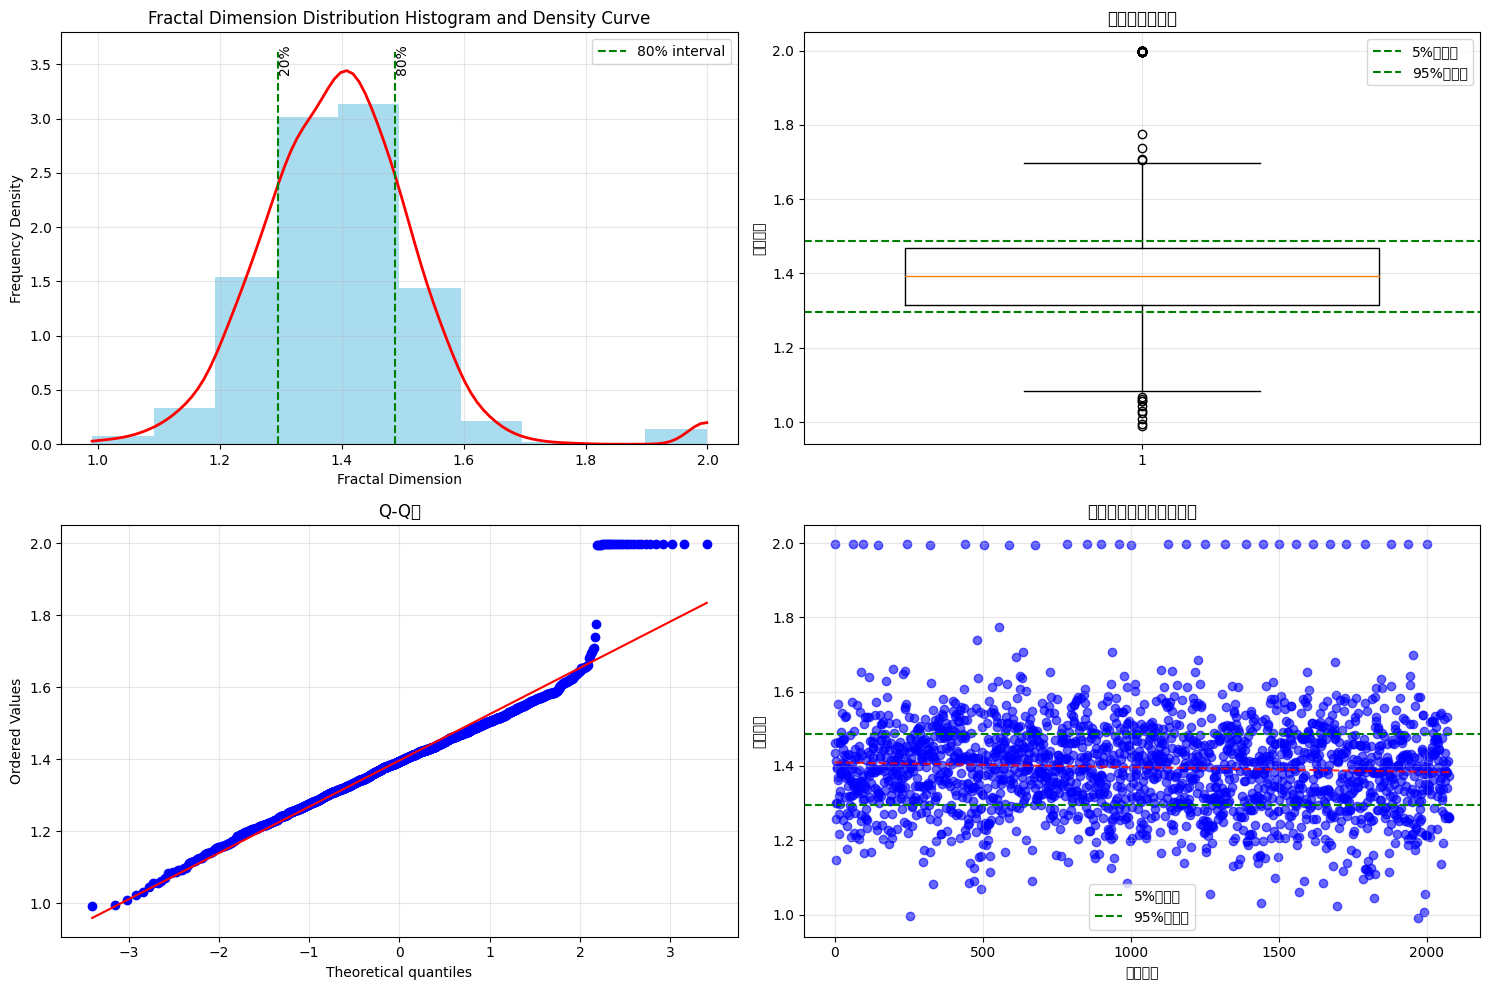

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def analyze_fractal_dimensions(fd_list):
    """
    分析分形维数数据并生成统计图表，包含分位数分析
    
    参数:
    fd_list: 分形维数列表
    """
    # 转换为numpy数组
    fd_array = np.array(fd_list)
    
    # 计算分位数
    percentile_5 = np.percentile(fd_array, 20)
    percentile_95 = np.percentile(fd_array, 80)
    
    # 计算基本统计量
    stats_dict = {
        "样本数量": len(fd_array),
        "平均值": np.mean(fd_array),
        "中位数": np.median(fd_array),
        "标准差": np.std(fd_array),
        "最小值": np.min(fd_array),
        "最大值": np.max(fd_array),
        "偏度": stats.skew(fd_array),
        "峰度": stats.kurtosis(fd_array),
        "5%分位数": percentile_5,
        "95%分位数": percentile_95,
        "90%区间范围": percentile_95 - percentile_5
    }
    
    # 打印统计结果
    print("\n统计分析结果:")
    print("-" * 30)
    for key, value in stats_dict.items():
        print(f"{key}: {value:.4f}")
    
    # 创建图形
    fig = plt.figure(figsize=(15, 10))
    
    # 1. 直方图和核密度估计，添加分位数标记
    ax1 = plt.subplot(2, 2, 1)
    counts, bins, _ = ax1.hist(fd_array, bins=10, density=True, alpha=0.7, color='skyblue')
    
    # 添加核密度估计曲线
    kernel = stats.gaussian_kde(fd_array)
    x_range = np.linspace(min(bins), max(bins), 100)
    ax1.plot(x_range, kernel(x_range), 'r-', lw=2)
    
    # 添加分位数标记
    ymin, ymax = ax1.get_ylim()
    ax1.vlines([percentile_5, percentile_95], ymin, ymax, colors=['g', 'g'], 
               linestyles='--', label='80% interval')
    ax1.text(percentile_5, ymax*0.95, '20%', rotation=90)
    ax1.text(percentile_95, ymax*0.95, '80%', rotation=90)
    
    ax1.set_title("Fractal Dimension Distribution Histogram and Density Curve")
    ax1.set_xlabel("Fractal Dimension")
    ax1.set_ylabel("Frequency Density")
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    # 2. 箱型图
    ax2 = plt.subplot(2, 2, 2)
    box_plot = ax2.boxplot(fd_array, vert=True, widths=0.7)
    
    # 添加分位数标记
    ax2.axhline(y=percentile_5, color='g', linestyle='--', label='5%分位数')
    ax2.axhline(y=percentile_95, color='g', linestyle='--', label='95%分位数')
    ax2.set_title("分形维数箱型图")
    ax2.set_ylabel("分形维数")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # 3. Q-Q图
    ax3 = plt.subplot(2, 2, 3)
    stats.probplot(fd_array, dist="norm", plot=ax3)
    ax3.set_title("Q-Q图")
    ax3.grid(True, alpha=0.3)
    
    # 4. 散点图和趋势线，添加分位数区间
    ax4 = plt.subplot(2, 2, 4)
    x = np.arange(len(fd_array))
    ax4.scatter(x, fd_array, alpha=0.6, color='blue')
    
    # 添加趋势线
    z = np.polyfit(x, fd_array, 1)
    p = np.poly1d(z)
    ax4.plot(x, p(x), "r--", alpha=0.8)
    
    # 添加分位数区间
    ax4.axhline(y=percentile_5, color='g', linestyle='--', label='5%分位数')
    ax4.axhline(y=percentile_95, color='g', linestyle='--', label='95%分位数')
    ax4.set_title("分形维数散点图和趋势线")
    ax4.set_xlabel("样本序号")
    ax4.set_ylabel("分形维数")
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    # 调整布局
    plt.tight_layout()
    
    # 输出90%区间的具体范围
    print("\n90%置信区间分析:")
    print("-" * 30)
    print(f"90%的数据落在区间: [{percentile_5:.4f}, {percentile_95:.4f}]")
    print(f"区间范围: {(percentile_95 - percentile_5):.4f}")
    
    return stats_dict, fig

def analyze_distribution(fd_array):
    """
    详细分析数据分布特征
    """
    # 计算数据区间分布
    bin_edges = np.linspace(min(fd_array), max(fd_array), 11)
    hist, bins = np.histogram(fd_array, bins=bin_edges)
    
    print("\n区间分布分析：")
    print("-" * 30)
    for i in range(len(hist)):
        print(f"区间 [{bins[i]:.4f}, {bins[i+1]:.4f}]: {hist[i]}个样本")
    
    # 正态性检验
    _, p_value = stats.normaltest(fd_array)
    print("\n正态性检验：")
    print("-" * 30)
    print(f"p值: {p_value:.4f}")
    print(f"结论: {'服从正态分布' if p_value > 0.05 else '不服从正态分布'}")


def preprocess_fractal_dimensions(Fd_list):
    """
    预处理分形维数列表，移除无效值
    
    参数:
    Fd_list: 原始分形维数列表
    
    返回:
    processed_list: 处理后的分形维数列表
    removed_count: 移除的元素数量
    """

    # 创建原始列表的副本以保留原始数据
    processed_list = Fd_list.copy()
    
    # 记录原始长度
    original_length = len(processed_list)
    
    # 移除值为0的元素
    try:
        while 0 in processed_list:
            processed_list.remove(0)
    except ValueError:
        pass  # 如果列表中没有0，跳过
    
    # 计算移除的元素数量
    removed_count = original_length - len(processed_list)
    
    # 打印处理结果
    print(f"预处理完成:")
    print(f"- 原始数据数量: {original_length}")
    print(f"- 移除的零值数量: {removed_count}")
    print(f"- 剩余数据数量: {len(processed_list)}")
    
    return processed_list, removed_count


# 示例使用
if __name__ == "__main__":
    file1_path = os.path.join('/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/test', 'fd_list')
    file2_path = os.path.join('/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/test', 'fd2_list')
    # 读取数据
    with open(file1_path, 'r') as f:
        loaded_data = [float(line.strip()) for line in f.readlines()]
        print("\n读取的数据:")
        print(loaded_data)
    # 预处理
    Fd_list_post,counts = preprocess_fractal_dimensions(loaded_data)
    print(Fd_list_post)
    # 进行分析
    stats_results, fig = analyze_fractal_dimensions(Fd_list_post)
    
    # 进行分布分析
    analyze_distribution(np.array(Fd_list_post))
    
    # 显示图形
    plt.show()
    
    # 保存图形（可选）
    # fig.savefig('fractal_dimension_analysis.png', dpi=300, bbox_inches='tight')